# Segment classification baselines

## Goal

- Train German GBERT classifiers to label reflection segments.
- The first pipeline is a four-classifier cascade: one binary scope model -> one four-class model for each skill dimension.
- The extension pipeline
  - shares the scope model
  - replaces each skill model with a presence classifier followed by a band classifier.

## Dataset

- Use the canonical `*_scope.csv` and `*_modeling_wide.csv` split files.
- Each row represents one candidate annotation bundle (`candidate_id`), not one unique text segment (`segment_id`).
- A segment can have multiple candidate bundles, so the same text may appear in multiple rows with different candidate labels.
- Keep those rows separate: do not deduplicate by segment or text, and do not merge their labels. These rows are alternative annotations of the same text, not additional unique segments.
- This notebook uses the wide file because each candidate has one row containing all three skill targets.
- The canonical `*_modeling_long.csv` is a reshaped view with three rows per candidate, one per skill dimension; it is not needed for these separate classifiers. All candidates from the same document and author stay in one split.
- Scope has 7,405 train, 1,851 dev, and 943 test candidates; the training classes are imbalanced (349 out-of-scope versus 7,056 in-scope).
- Skill targets are available only for in-scope candidates. Class `0` means the skill dimension is absent; classes `1`, `2`, and `3` are bands A, B, and C. Treat them as categorical classes, not an equally spaced numeric scale.
- Rare bands limit conclusions: situationserfassung band 3 has 21 training examples and none in test; konsequenzen band 3 has 38 training examples and 8 in test.
- The test split contains 24 documents from 8 authors, including the 22 feedback-available reflections. Interpret test results with that cohort composition in mind.

## Experiment versions

1. **Direct multiclass baseline (4 classifiers):** one scope classifier (2 classes) plus three independent skill classifiers (4 classes each: absent, A, B, C). This is the primary fast baseline.
2. **Presence-then-band (7 classifiers):** the same shared scope classifier, plus one binary presence classifier and one three-class band classifier for each of the three skills: 1 scope + 3 presence + 3 band. For each skill, train the presence classifier on all in-scope candidates with known targets (`0` = absent; `1-3` = present), and train its band classifier only on present candidates (A, B, or C). At inference, an absent prediction maps to class `0`; a present prediction uses the corresponding band prediction, mapped to classes `1-3`. This tests whether separating presence from band prediction helps, at the cost of three additional classifiers and smaller band-training sets.

- Both versions use the same GBERT encoder and segment text. 
- Training is opt-in below because it downloads the model and trains multiple heads. 
- Choose hyperparameters on dev only; reserve test for final reporting. 
- Report macro-F1 and per-class precision/recall/F1, and distinguish skill performance on gold in-scope rows from the end-to-end pipeline where scope mistakes can propagate. 
- Out-of-scope is a separate end-to-end outcome, not skill class 0.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from reflection_assessment_feedback.experiment_config import load_experiment_config

PROJECT_ROOT = Path.cwd().resolve()
assert PROJECT_ROOT.name == "prebi_v1", "Run this notebook from the prebi_v1 project root."
EXPERIMENT_CONFIG = load_experiment_config()
SPLIT_DIR = PROJECT_ROOT / EXPERIMENT_CONFIG["paths"]["provisional_split_directory"]
SPLITS = tuple(EXPERIMENT_CONFIG["dataset"]["split_names"])
SKILLS = EXPERIMENT_CONFIG["labels"]["skill_targets"]

wide_data = {
    split: pd.read_csv(SPLIT_DIR / f"provisional_{split}_modeling_wide.csv")
    for split in SPLITS
}
scope_data = {
    split: pd.read_csv(SPLIT_DIR / f"provisional_{split}_scope.csv")
    for split in SPLITS
}

for split in SPLITS:
    assert wide_data[split]["candidate_id"].is_unique
    assert scope_data[split]["candidate_id"].is_unique
    assert set(wide_data[split]["candidate_id"]) == set(scope_data[split]["candidate_id"])
    in_scope = wide_data[split].loc[wide_data[split]["component"] == "in_scope"]
    assert in_scope[list(SKILLS.values())].notna().all().all()

print(f"PyTorch: {torch.__version__}; Transformers: {transformers.__version__}")
pd.DataFrame(
    {
        split: {
            "scope candidates": len(scope_data[split]),
            "in-scope candidates": int((wide_data[split]["component"] == "in_scope").sum()),
        }
        for split in SPLITS
    }
)

/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.14.0; Transformers: 4.57.6


,train,dev,test
scope candidates,7107,1823,905
in-scope candidates,6765,1739,874


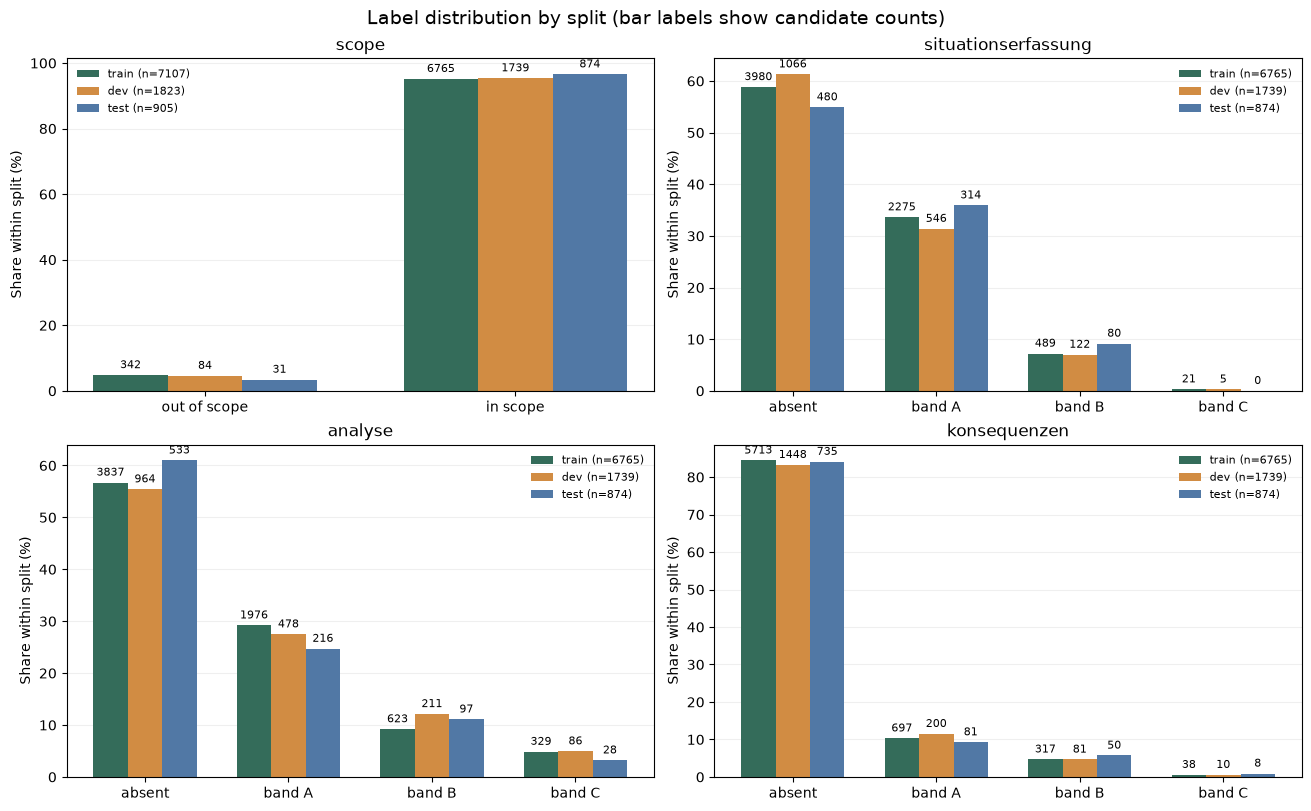

In [2]:
LABELS = {
    "scope": ["out of scope", "in scope"],
    **{
        skill: ["absent", "band A", "band B", "band C"]
        for skill in SKILLS
    },
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
plot_tasks = ["scope", *SKILLS]
colors = {"train": "#346C5A", "dev": "#D18C43", "test": "#5178A5"}

for axis, task in zip(axes.flat, plot_tasks):
    split_counts = {}
    for split in SPLITS:
        if task == "scope":
            labels = scope_data[split]["scope_target"].astype(int)
        else:
            rows = wide_data[split].loc[wide_data[split]["component"] == "in_scope"]
            labels = rows[SKILLS[task]].astype(int)
        split_counts[split] = labels.value_counts().reindex(range(len(LABELS[task])), fill_value=0)

    positions = np.arange(len(LABELS[task]))
    width = 0.24
    for split_index, split in enumerate(SPLITS):
        counts = split_counts[split]
        percentages = counts / counts.sum() * 100
        offset = (split_index - 1) * width
        bars = axis.bar(
            positions + offset,
            percentages,
            width,
            label=f"{split} (n={int(counts.sum())})",
            color=colors[split],
        )
        for bar, count, percentage in zip(bars, counts, percentages):
            axis.annotate(
                f"{int(count)}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    axis.set_title(task)
    axis.set_xticks(positions, LABELS[task])
    axis.set_ylabel("Share within split (%)")
    axis.grid(axis="y", alpha=0.2)
    axis.set_axisbelow(True)
    axis.legend(frameon=False, fontsize=8)

fig.suptitle("Label distribution by split (bar labels show candidate counts)", fontsize=14)
plt.show()

## Training setup

- The chart shows the within-split percentage for each class; labels above bars are raw candidate counts. 
- The skill panels use in-scope candidates only. 
- The weighted loss below uses the square root of inverse class frequency, capped and normalized, to give rare labels more influence without the extreme weights of fully balanced sampling. 
- Check dev macro-F1 and per-class scores before drawing conclusions about the rare bands.

In [ ]:
import gc
import json
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from reflection_assessment_feedback.experiment_config import (
    experiment_config_sha256,
    load_experiment_config,
)

EXPERIMENT_CONFIG = load_experiment_config()
CLASSIFIER_CONFIG = EXPERIMENT_CONFIG["classifier"]
MODEL_NAME = CLASSIFIER_CONFIG["model_name"]
MODEL_REVISION = CLASSIFIER_CONFIG["model_revision"] or None
MAX_LENGTH = CLASSIFIER_CONFIG["max_length"]
BATCH_SIZE = CLASSIFIER_CONFIG["batch_size"]
EPOCHS = CLASSIFIER_CONFIG["epochs"]
LEARNING_RATE = CLASSIFIER_CONFIG["learning_rate"]
WEIGHT_DECAY = CLASSIFIER_CONFIG["weight_decay"]
EARLY_STOPPING_PATIENCE = CLASSIFIER_CONFIG["early_stopping_patience"]
EARLY_STOPPING_MIN_DELTA = CLASSIFIER_CONFIG["early_stopping_min_delta"]
CLASS_WEIGHT_MIN = CLASSIFIER_CONFIG["class_weight_min"]
CLASS_WEIGHT_MAX = CLASSIFIER_CONFIG["class_weight_max"]
WARMUP_RATIO = CLASSIFIER_CONFIG["warmup_ratio"]
GRADIENT_CLIP_NORM = CLASSIFIER_CONFIG["gradient_clip_norm"]
RUN_DIR = PROJECT_ROOT / EXPERIMENT_CONFIG["paths"]["classifier_checkpoints"]
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"Training device: {DEVICE}")


def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_data_loader(frame, tokenizer, label_col=None, shuffle=False):
    texts = frame["text"].fillna("").astype(str).tolist()
    labels = None if label_col is None else frame[label_col].astype(int).to_numpy()

    def collate_rows(row_indices):
        indices = [int(index) for index in row_indices]
        batch_texts = [texts[index] for index in indices]
        batch = tokenizer(
            batch_texts,
            truncation=True,
            max_length=MAX_LENGTH,
            padding=True,
            return_tensors="pt",
        )
        batch = {key: value.to(DEVICE) for key, value in batch.items()}
        if labels is not None:
            batch["labels"] = torch.tensor(labels[indices], dtype=torch.long, device=DEVICE)
        return batch

    return DataLoader(
        torch.arange(len(texts)),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        collate_fn=collate_rows,
    )


def predict_from_loader(model, data_loader):
    model.eval()
    predictions = []
    gold_labels = []
    with torch.inference_mode():
        for batch in data_loader:
            labels = batch.pop("labels", None)
            logits = model(**batch).logits
            predictions.extend(logits.argmax(dim=1).cpu().numpy())
            if labels is not None:
                gold_labels.extend(labels.cpu().numpy())
    return np.asarray(predictions), np.asarray(gold_labels, dtype=int)


def fit_gbert_classifier(train_frame, dev_frame, label_col, num_labels, run_name, tokenizer):
    set_seed()
    train_labels = train_frame[label_col].astype(int).to_numpy()
    class_counts = np.bincount(train_labels, minlength=num_labels)
    if len(class_counts) != num_labels or (class_counts == 0).any():
        raise ValueError(f"Training data for {run_name} is missing one or more classes: {class_counts}")

    train_loader = make_data_loader(train_frame, tokenizer, label_col, shuffle=True)
    dev_loader = make_data_loader(dev_frame, tokenizer, label_col)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        revision=MODEL_REVISION,
        num_labels=num_labels,
    ).to(DEVICE)
    model.config.problem_type = "single_label_classification"

    class_weights = np.sqrt(class_counts.sum() / class_counts)
    class_weights = class_weights / class_weights.mean()
    class_weights = np.clip(class_weights, CLASS_WEIGHT_MIN, CLASS_WEIGHT_MAX)
    class_weights = class_weights / class_weights.mean()
    loss_function = torch.nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
    )
    print(
        f"{run_name}: weighted CrossEntropyLoss, "
        f"class counts={class_counts.tolist()}, "
        f"class weights={class_weights.round(3).tolist()}"
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    total_steps = max(1, len(train_loader) * EPOCHS)
    warmup_steps = max(1, int(total_steps * WARMUP_RATIO))

    def learning_rate_scale(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        return max(0.0, (total_steps - step) / max(1, total_steps - warmup_steps))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, learning_rate_scale)
    checkpoint_path = RUN_DIR / f"{run_name}.pt"
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    best_macro_f1 = -1.0
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        batch_losses = []
        with tqdm(train_loader, desc=f"{run_name} epoch {epoch}/{EPOCHS}", unit="batch") as progress:
            for batch in progress:
                labels = batch.pop("labels")
                optimizer.zero_grad(set_to_none=True)
                logits = model(**batch).logits
                loss = loss_function(logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRADIENT_CLIP_NORM)
                optimizer.step()
                scheduler.step()
                batch_losses.append(loss.item())
                progress.set_postfix(train_loss=f"{np.mean(batch_losses):.4f}")

        dev_predictions, dev_labels = predict_from_loader(model, dev_loader)
        dev_macro_f1 = f1_score(
            dev_labels,
            dev_predictions,
            labels=np.arange(num_labels),
            average="macro",
            zero_division=0,
        )
        history.append(
            {
                "epoch": epoch,
                "train_loss": float(np.mean(batch_losses)),
                "dev_macro_f1": float(dev_macro_f1),
            }
        )
        print(
            f"{run_name}: epoch {epoch}/{EPOCHS}, "
            f"train loss={history[-1]['train_loss']:.4f}, dev macro-F1={dev_macro_f1:.4f}"
        )

        if dev_macro_f1 > best_macro_f1 + EARLY_STOPPING_MIN_DELTA:
            best_macro_f1 = float(dev_macro_f1)
            epochs_without_improvement = 0
            torch.save(
                {key: value.detach().cpu() for key, value in model.state_dict().items()},
                checkpoint_path,
            )
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                break

    del model, optimizer, scheduler, train_loader, dev_loader
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    result = {
        "checkpoint": str(checkpoint_path),
        "num_labels": num_labels,
        "history": history,
        "best_dev_macro_f1": best_macro_f1,
        "experiment_config_sha256": experiment_config_sha256(),
        "experiment_config": EXPERIMENT_CONFIG,
    }
    (RUN_DIR / f"{run_name}.json").write_text(json.dumps(result, indent=2))
    return result


def fit_or_load_gbert_classifier(train_frame, dev_frame, label_col, num_labels, run_name, tokenizer):
    metadata_path = RUN_DIR / f"{run_name}.json"
    if REUSE_COMPLETED_RUNS and metadata_path.is_file():
        result = json.loads(metadata_path.read_text())
        if result["num_labels"] != num_labels or not Path(result["checkpoint"]).is_file():
            raise ValueError(f"Incomplete or incompatible saved run: {run_name}")
        print(f"{run_name}: loading completed run (dev macro-F1={result['best_dev_macro_f1']:.4f})")
        return result
    return fit_gbert_classifier(train_frame, dev_frame, label_col, num_labels, run_name, tokenizer)


def predict_gbert(model_info, frame, tokenizer):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        revision=MODEL_REVISION,
        num_labels=model_info["num_labels"],
    )
    state = torch.load(model_info["checkpoint"], map_location="cpu", weights_only=True)
    model.load_state_dict(state)
    model.to(DEVICE)
    data_loader = make_data_loader(frame, tokenizer)
    predictions, _ = predict_from_loader(model, data_loader)
    del model, data_loader
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    return predictions

In [ ]:
import hashlib
from datetime import datetime, timezone
import shutil

SPLIT_SHA256 = {
    f'{split}_{view}': hashlib.sha256(
        (SPLIT_DIR / f'provisional_{split}_{view}.csv').read_bytes()
    ).hexdigest()
    for split in SPLITS for view in ('scope', 'modeling_wide')
}
for left, right in [('train', 'dev'), ('train', 'test'), ('dev', 'test')]:
    for column in ('document_id', 'author_id', 'segment_id'):
        assert not (set(wide_data[left][column]) & set(wide_data[right][column])), f'{column} leakage'
for split in SPLITS:
    assert scope_data[split]['scope_target_known'].all()
    assert scope_data[split]['scope_target'].isin([0, 1]).all()
    assert not wide_data[split]['scope_unresolved'].any()
    assert wide_data[split]['text'].fillna('').str.strip().str.len().ge(10).all()
    in_scope = wide_data[split]['scope_target'].eq(1)
    for skill, target in SKILLS.items():
        assert wide_data[split].loc[in_scope, f'known_{skill}'].all()
        assert wide_data[split].loc[in_scope, target].isin([0, 1, 2, 3]).all()

RETRAIN_RUN_ID = datetime.now(timezone.utc).strftime('retrain-%Y%m%dT%H%M%S%fZ')
RUN_DIR = PROJECT_ROOT / 'artifacts' / 'segment-classification' / RETRAIN_RUN_ID
assert shutil.disk_usage(PROJECT_ROOT).free > 6 * 1024**3, 'Need at least 6 GiB free for new checkpoints.'
RUN_DIR.mkdir(parents=True, exist_ok=False)

_original_fit_gbert_classifier = fit_gbert_classifier

def fit_gbert_classifier(train_frame, dev_frame, label_col, num_labels, run_name, tokenizer):
    result = _original_fit_gbert_classifier(
        train_frame, dev_frame, label_col, num_labels, run_name, tokenizer,
    )
    result.update({
        'split_sha256': SPLIT_SHA256,
        'training_rows': len(train_frame), 'development_rows': len(dev_frame),
        'training_run_id': RETRAIN_RUN_ID,
        'selection_split': 'dev', 'test_used_for_training': False,
    })
    (RUN_DIR / f'{run_name}.json').write_text(json.dumps(result, indent=2), encoding='utf-8')
    return result

print('New checkpoint directory:', RUN_DIR)
print('Split hashes and label-quality checks ready; original checkpoints are unchanged.')

In [ ]:
from transformers import AutoConfig


def load_gbert_assets():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
    model_config = AutoConfig.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
    if model_config.model_type != "bert":
        raise ValueError(f"Expected a BERT config for {MODEL_NAME}, got {model_config.model_type!r}")
    return tokenizer, model_config


PREPARE_MODEL_ASSETS = True
tokenizer = None
model_config = None
if PREPARE_MODEL_ASSETS:
    tokenizer, model_config = load_gbert_assets()
    print(f"GBERT tokenizer and {model_config.model_type} config are ready; Hub cache will be reused.")

## Train and evaluate

The current filtered split has 7,107 train, 1,823 dev, and 905 test scope candidates. In-scope skill counts are 6,765 / 1,739 / 874. Unresolved scope and unknown applicable skill labels are excluded by the canonical export; the retraining preflight verifies labels, text quality, and author/document/segment separation.

Run the isolated-retraining setup after defining training functions. It creates a new timestamped directory under `artifacts/segment-classification/`, preserves existing checkpoints, and records SHA-256 hashes of the scope and wide split files in every completed model. Do not rerun that setup midway through training: it creates another run directory.

Use the group switches to train scope, direct, and presence/band models. Checkpoints are selected on dev macro-F1 only. The validation cell after hierarchical training verifies all ten checkpoints and saves `dev-summary.csv` and `run-manifest.json`, including checkpoint hashes.

Completed current-split run: `artifacts/segment-classification/retrain-20261003T125604532027Z`. All ten models finished and were validated; no test evaluation was executed during retraining. The shared experiment config still points to the previous checkpoint directory, preserving existing downstream workflows. To compare the new direct cascade in `05_segment_evaluation.ipynb`, set `GBERT_CHECKPOINT_DIR` to this run directory before executing comparison.

The final cell evaluates test only when `RUN_EVALUATION=True`. Do not execute it until models and settings have been frozen. Existing test results elsewhere describe the previous checkpoints, not this retrained run.

In [ ]:
RUN_SCOPE = True
RUN_DIRECT = True
RUN_HIERARCHICAL = True
REUSE_COMPLETED_RUNS = False
training_results = {"scope": {}, "direct": {}, "presence": {}, "band": {}}
scope_frames = {
    split: scope_data[split].loc[scope_data[split]["scope_target_known"]].copy()
    for split in SPLITS
}

if RUN_SCOPE:
    if tokenizer is None:
        tokenizer, model_config = load_gbert_assets()
    training_results["scope"] = fit_or_load_gbert_classifier(
        scope_frames["train"],
        scope_frames["dev"],
        label_col="scope_target",
        num_labels=2,
        run_name="scope",
        tokenizer=tokenizer,
    )
else:
    print("Scope training skipped. Set RUN_SCOPE = True to train or load it.")

In [ ]:
if RUN_DIRECT:
    if tokenizer is None:
        tokenizer, model_config = load_gbert_assets()
    skill_frames = {
        split: wide_data[split].loc[wide_data[split]["component"] == "in_scope"].copy()
        for split in SPLITS
    }
    for skill, target_col in SKILLS.items():
        training_results["direct"][skill] = fit_or_load_gbert_classifier(
            skill_frames["train"],
            skill_frames["dev"],
            label_col=target_col,
            num_labels=4,
            run_name=f"direct-{skill}",
            tokenizer=tokenizer,
        )
else:
    print("Direct skill training skipped. Set RUN_DIRECT = True to train or load it.")

In [ ]:
if RUN_HIERARCHICAL:
    if tokenizer is None:
        tokenizer, model_config = load_gbert_assets()
    skill_frames = {
        split: wide_data[split].loc[wide_data[split]["component"] == "in_scope"].copy()
        for split in SPLITS
    }
    for skill, target_col in SKILLS.items():
        presence_frames = {}
        band_frames = {}
        for split, frame in skill_frames.items():
            presence_frame = frame.copy()
            presence_frame["presence_label"] = (presence_frame[target_col].astype(int) > 0).astype(int)
            presence_frames[split] = presence_frame
            band_frames[split] = frame.loc[frame[target_col].astype(int) > 0].copy()
            band_frames[split]["band_label"] = band_frames[split][target_col].astype(int) - 1

        training_results["presence"][skill] = fit_or_load_gbert_classifier(
            presence_frames["train"],
            presence_frames["dev"],
            label_col="presence_label",
            num_labels=2,
            run_name=f"presence-{skill}",
            tokenizer=tokenizer,
        )
        training_results["band"][skill] = fit_or_load_gbert_classifier(
            band_frames["train"],
            band_frames["dev"],
            label_col="band_label",
            num_labels=3,
            run_name=f"band-{skill}",
            tokenizer=tokenizer,
        )
else:
    print("Presence/band training skipped. Set RUN_HIERARCHICAL = True to train or load it.")

In [ ]:
completed_models = [('scope', training_results['scope'])]
for group in ('direct', 'presence', 'band'):
    completed_models.extend((f'{group}-{skill}', result) for skill, result in training_results[group].items())
assert len(completed_models) == 10, 'All ten models must finish before run validation.'
run_summary = []
for run_name, result in completed_models:
    assert result['split_sha256'] == SPLIT_SHA256
    assert result['selection_split'] == 'dev' and result['test_used_for_training'] is False
    checkpoint = Path(result['checkpoint'])
    assert checkpoint.parent == RUN_DIR and checkpoint.is_file()
    state = torch.load(checkpoint, map_location='cpu', weights_only=True)
    assert state['classifier.weight'].shape[0] == result['num_labels']
    assert all(torch.isfinite(value).all().item() for value in state.values() if value.is_floating_point())
    del state
    run_summary.append({
        'run': run_name, 'training_rows': result['training_rows'],
        'dev_rows': result['development_rows'], 'best_dev_macro_f1': result['best_dev_macro_f1'],
        'epochs': len(result['history']),
    })
    with checkpoint.open('rb') as checkpoint_file:
        result['checkpoint_sha256'] = hashlib.file_digest(checkpoint_file, 'sha256').hexdigest()
    (RUN_DIR / f'{run_name}.json').write_text(json.dumps(result, indent=2), encoding='utf-8')

pd.DataFrame(run_summary).to_csv(RUN_DIR / 'dev-summary.csv', index=False)
(RUN_DIR / 'run-manifest.json').write_text(json.dumps({
    'training_run_id': RETRAIN_RUN_ID, 'split_sha256': SPLIT_SHA256,
    'selection_split': 'dev', 'test_used_for_training': False,
    'models': {name: {'checkpoint_sha256': result['checkpoint_sha256'], 'num_labels': result['num_labels']}
               for name, result in completed_models},
}, indent=2), encoding='utf-8')
display(pd.DataFrame(run_summary).round(4))
print('All ten checkpoint tensors and split fingerprints validated. Test evaluation was not run.')

In [ ]:
def report_task(name, gold, predictions, labels, target_names):
    summary = {
        "task": name,
        "n": int(len(gold)),
        "accuracy": float(accuracy_score(gold, predictions)),
        "macro_f1": float(
            f1_score(gold, predictions, labels=labels, average="macro", zero_division=0)
        ),
        "weighted_f1": float(
            f1_score(gold, predictions, labels=labels, average="weighted", zero_division=0)
        ),
    }
    print(name)
    print(
        classification_report(
            gold,
            predictions,
            labels=labels,
            target_names=target_names,
            zero_division=0,
        )
    )
    print("Confusion matrix (gold rows, predicted columns):")
    print(confusion_matrix(gold, predictions, labels=labels))
    return summary


RUN_EVALUATION = True
if RUN_EVALUATION:
    missing = [
        name for name, models in training_results.items()
        if not models or (name != "scope" and set(models) != set(SKILLS))
    ]
    if missing:
        raise ValueError(f"Train or load all models before test evaluation; missing: {missing}")
    test_scope = scope_frames["test"].reset_index(drop=True)
    test_wide = wide_data["test"].reset_index(drop=True).copy()
    scope_predictions = predict_gbert(
        training_results["scope"],
        test_scope,
        tokenizer,
    )
    scope_gold = test_scope["scope_target"].astype(int).to_numpy()
    evaluation_rows = [
        report_task("scope", scope_gold, scope_predictions, [0, 1], LABELS["scope"])
    ]

    scope_prediction_by_candidate = pd.Series(
        scope_predictions,
        index=test_scope["candidate_id"],
    )
    scope_gold_by_candidate = test_scope.set_index("candidate_id")["scope_target"].astype(int)
    test_wide["gold_scope"] = test_wide["candidate_id"].map(scope_gold_by_candidate).astype(int)
    test_wide["predicted_scope"] = test_wide["candidate_id"].map(scope_prediction_by_candidate).astype(int)
    end_to_end_labels = ["out of scope", "absent", "band A", "band B", "band C"]

    for skill, target_col in SKILLS.items():
        in_scope_test = test_wide.loc[test_wide["gold_scope"] == 1].copy().reset_index(drop=True)
        gold_skill = in_scope_test[target_col].astype(int).to_numpy()

        direct_predictions = predict_gbert(
            training_results["direct"][skill],
            in_scope_test,
            tokenizer,
        )
        evaluation_rows.append(
            report_task(
                f"{skill} direct (gold in-scope)",
                gold_skill,
                direct_predictions,
                [0, 1, 2, 3],
                LABELS[skill],
            )
        )

        presence_predictions = predict_gbert(
            training_results["presence"][skill],
            in_scope_test,
            tokenizer,
        )
        band_predictions = predict_gbert(
            training_results["band"][skill],
            in_scope_test,
            tokenizer,
        )
        hierarchical_predictions = np.where(
            presence_predictions == 0,
            0,
            band_predictions + 1,
        )
        evaluation_rows.append(
            report_task(
                f"{skill} presence-then-band (gold in-scope)",
                gold_skill,
                hierarchical_predictions,
                [0, 1, 2, 3],
                LABELS[skill],
            )
        )

        predicted_in_scope = test_wide.loc[test_wide["predicted_scope"] == 1].copy()
        end_to_end_gold = np.zeros(len(test_wide), dtype=int)
        end_to_end_direct = np.zeros(len(test_wide), dtype=int)
        end_to_end_hierarchical = np.zeros(len(test_wide), dtype=int)
        gold_in_scope_mask = test_wide["gold_scope"].to_numpy() == 1
        end_to_end_gold[gold_in_scope_mask] = test_wide.loc[gold_in_scope_mask, target_col].astype(int) + 1

        direct_all_predictions = predict_gbert(
            training_results["direct"][skill],
            predicted_in_scope,
            tokenizer,
        )
        predicted_scope_mask = test_wide["predicted_scope"].to_numpy() == 1
        end_to_end_direct[predicted_scope_mask] = direct_all_predictions + 1

        presence_all_predictions = predict_gbert(
            training_results["presence"][skill],
            predicted_in_scope,
            tokenizer,
        )
        band_all_predictions = predict_gbert(
            training_results["band"][skill],
            predicted_in_scope,
            tokenizer,
        )
        end_to_end_hierarchical[predicted_scope_mask] = np.where(
            presence_all_predictions == 0,
            1,
            band_all_predictions + 2,
        )

        evaluation_rows.append(
            report_task(
                f"{skill} direct (end-to-end)",
                end_to_end_gold,
                end_to_end_direct,
                [0, 1, 2, 3, 4],
                end_to_end_labels,
            )
        )
        evaluation_rows.append(
            report_task(
                f"{skill} presence-then-band (end-to-end)",
                end_to_end_gold,
                end_to_end_hierarchical,
                [0, 1, 2, 3, 4],
                end_to_end_labels,
            )
        )

    evaluation_summary = pd.DataFrame(evaluation_rows)
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    evaluation_summary.to_csv(RUN_DIR / "test-summary.csv", index=False)
    print(evaluation_summary.to_string(index=False))
else:
    print("Test evaluation skipped. Set RUN_EVALUATION = True after model selection.")

In [ ]:
RUN_GEMINI_PILOT = True
GEMINI_PILOT_DOCUMENT_COUNT = 2

if RUN_GEMINI_PILOT:
    import json
    import os

    from dotenv import load_dotenv
    from reflection_assessment_feedback.segment_classification_gemini import SegmentClassifierGemini

    load_dotenv(PROJECT_ROOT / ".env", override=False)
    gemini_scope_dev = scope_data["dev"].loc[
        scope_data["dev"]["scope_target_known"],
        ["candidate_id", "document_id", "segment_id", "segment_order", "text", "scope_target"],
    ]
    gemini_skill_dev = wide_data["dev"].loc[
        wide_data["dev"]["component"] == "in_scope",
        ["candidate_id", *SKILLS.values()],
    ]
    gemini_dev = gemini_scope_dev.merge(
        gemini_skill_dev, on="candidate_id", how="left", validate="one_to_one",
    )
    gemini_pilot_document_ids = gemini_dev["document_id"].drop_duplicates().sample(
        n=min(GEMINI_PILOT_DOCUMENT_COUNT, gemini_dev["document_id"].nunique()),
        random_state=EXPERIMENT_CONFIG["evaluation"]["random_seed"],
    )
    gemini_pilot_rows = gemini_dev.loc[
        gemini_dev["document_id"].isin(gemini_pilot_document_ids)
    ].reset_index(drop=True)
    gemini_protected_root_value = os.getenv("PREBI_DATA_ROOT")
    if not gemini_protected_root_value:
        raise RuntimeError("Set PREBI_DATA_ROOT for the protected Gemini rate-limit state.")
    gemini_protected_root = Path(gemini_protected_root_value).expanduser().resolve()
    if gemini_protected_root == PROJECT_ROOT or PROJECT_ROOT in gemini_protected_root.parents:
        raise ValueError("PREBI_DATA_ROOT must be outside the project source tree.")

    gemini_classifier = SegmentClassifierGemini.from_google_gemini(
        model_name=EXPERIMENT_CONFIG["generation"]["model_name"],
        temperature=EXPERIMENT_CONFIG["generation"]["temperature"],
        enable_langsmith_tracing=EXPERIMENT_CONFIG["generation"]["enable_langsmith_tracing"],
        minimum_request_interval_seconds=EXPERIMENT_CONFIG["generation"]["minimum_request_interval_seconds"],
        rate_limit_state_path=gemini_protected_root / ".rate_limits" / "gemini.state",
    )
    gemini_report = gemini_classifier.evaluate(gemini_pilot_rows)
    print(json.dumps({
        "documents": int(gemini_pilot_rows["document_id"].nunique()),
        "candidate_rows": len(gemini_pilot_rows),
        "gemini_requests": gemini_classifier.request_count,
        "selection_macro_f1": gemini_report["selection_macro_f1"],
        "selection_policy": gemini_report["selection_policy"],
    }, indent=2))
else:
    print("Gemini pilot skipped. Set RUN_GEMINI_PILOT = True to classify a small development-document sample.")

/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.
/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/c

{
  "rows": 8,
  "selection_macro_f1": 0.40740740740740744,
  "selection_policy": "Mean end-to-end macro-F1 across skills, over gold-supported labels"
}


In [4]:
gemini_report

{'rows': 8,
 'reports': {'scope': {'0': {'precision': 1.0,
    'recall': 0.5,
    'f1-score': 0.6666666666666666,
    'support': 4.0},
   '1': {'precision': 0.6666666666666666,
    'recall': 1.0,
    'f1-score': 0.8,
    'support': 4.0},
   'accuracy': 0.75,
   'macro avg': {'precision': 0.8333333333333333,
    'recall': 0.75,
    'f1-score': 0.7333333333333334,
    'support': 8.0},
   'weighted avg': {'precision': 0.8333333333333333,
    'recall': 0.75,
    'f1-score': 0.7333333333333334,
    'support': 8.0}},
  'SW_gold_scope': {'0': {'precision': 0.0,
    'recall': 0.0,
    'f1-score': 0.0,
    'support': 2.0},
   '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
   '2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 2.0},
   '3': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
   'accuracy': 0.0,
   'macro avg': {'precision': 0.0,
    'recall': 0.0,
    'f1-score': 0.0,
    'support': 4.0},
   'weighted avg': {'precision': 0